# **Farnebäck**

En esta sección, implementamos el método de Farnebäck. El código lo extrajimos de la página oficial de [OpenCv](https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html).

In [ ]:
import numpy as np
import cv2 as cv
import os 

os.makedirs("output/farneback", exist_ok=True)
cap = cv.VideoCapture(cv.samples.findFile("videos/people2.mp4"))
ret, frame1 = cap.read()
prvs = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)
hsv = np.zeros_like(frame1)
hsv[..., 1] = 255
while(1):
    ret, frame2 = cap.read()
    if not ret:
        print('No frames grabbed!')
        break
    next = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)
    flow = cv.calcOpticalFlowFarneback(prvs, next, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    mag, ang = cv.cartToPolar(flow[..., 0], flow[..., 1])
    hsv[..., 0] = ang*180/np.pi/2
    hsv[..., 2] = cv.normalize(mag, None, 0, 255, cv.NORM_MINMAX)
    bgr = cv.cvtColor(hsv, cv.COLOR_HSV2BGR)
    cv.imshow('frame2', bgr)
    k = cv.waitKey(30) & 0xff
    if k == 27:
        break
    elif k == ord('s'):
        cv.imwrite('output/farneback/opticalfb.png', frame2)
        cv.imwrite('output/farneback/opticalhsv.png', bgr)
    prvs = next
cv.destroyAllWindows()


Si guardamos un frame con la tecla `S`, obtenemos lo siguiente:
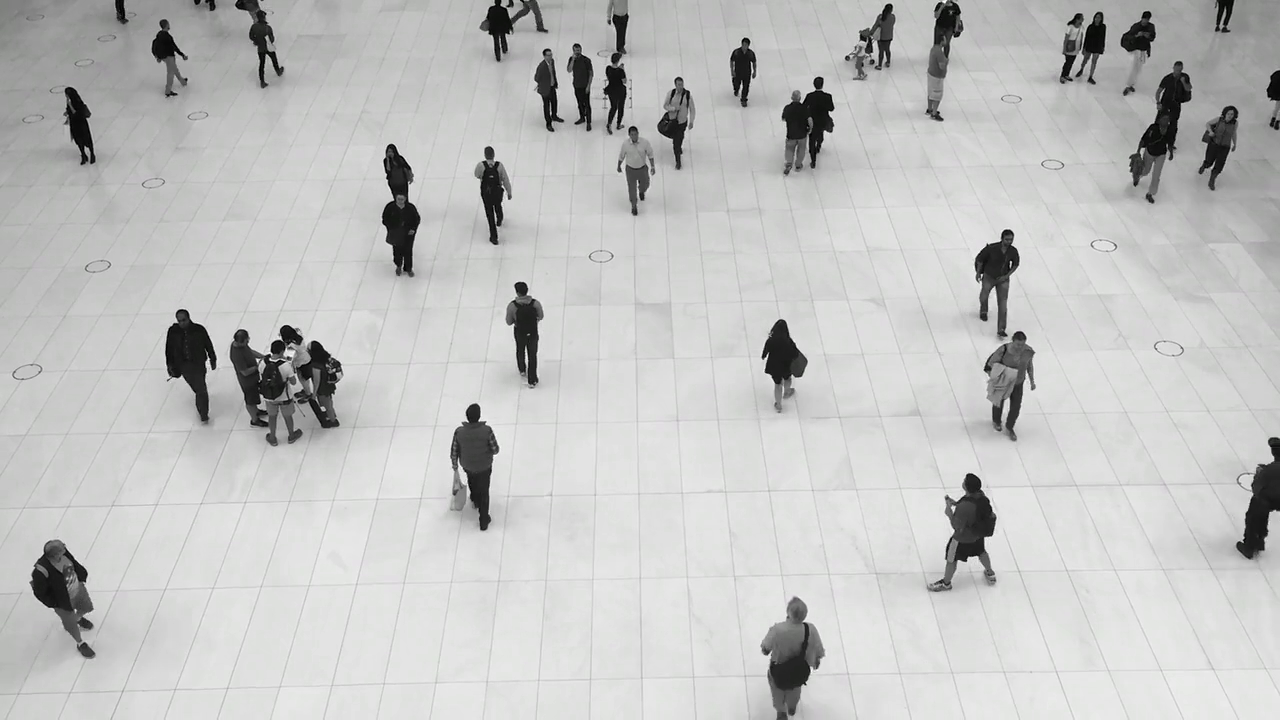
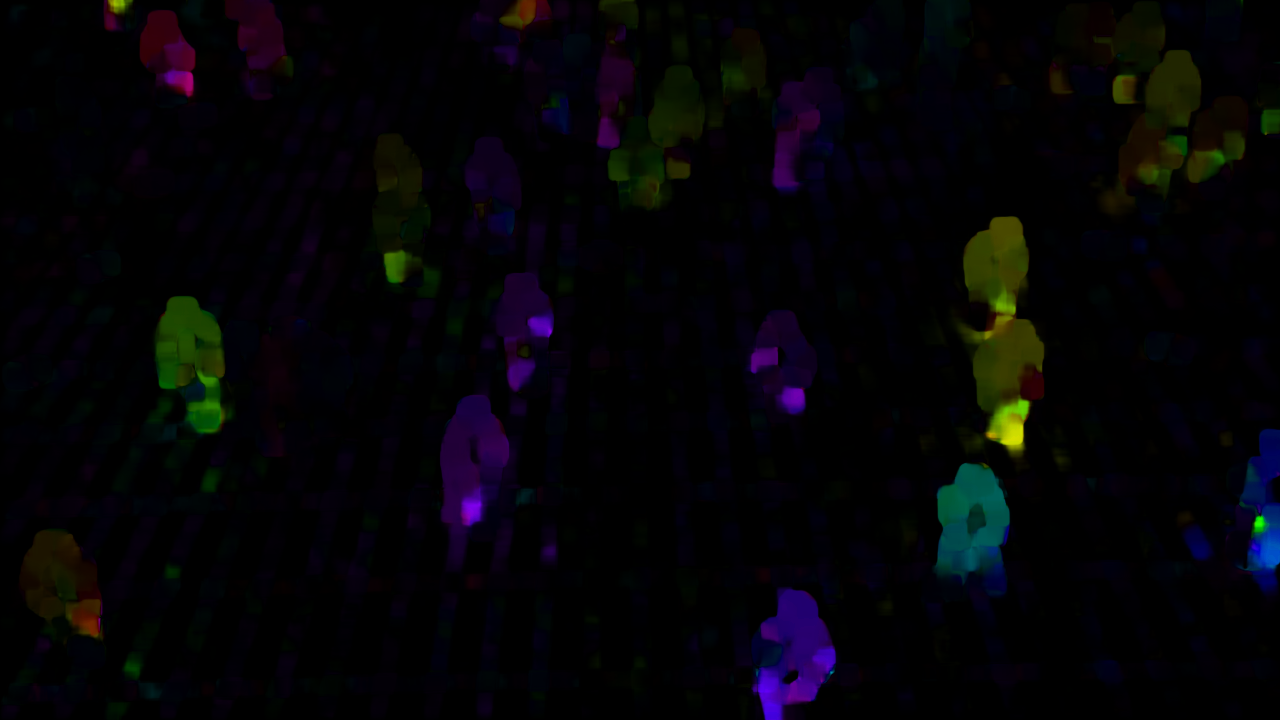